# Grid MADRL Mainline

This notebook keeps the main workflow short: configure -> train -> test -> compare with MPC.


In [1]:
from pathlib import Path
import sys
import warnings

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / 'configs').exists():
    project_root = project_root.parent
if not (project_root / 'configs').exists():
    raise RuntimeError('Could not locate the project root.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Python executable: {sys.executable}')
try:
    import gymnasium as gym
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "Gymnasium is required for this notebook. Install gymnasium==0.29.1 in the active kernel environment."
    ) from exc
print(f'Gymnasium version: {gym.__version__}')

warnings.filterwarnings('ignore', message='The behavior of DataFrame concatenation with empty or all-NA entries is deprecated.*')
project_root


Python executable: d:\SOFTWARE\miniconda\envs\MADRL_ESS\python.exe
Gymnasium version: 0.29.1


WindowsPath('D:/GithubProject/MADRL_ESS')

In [2]:
import json
import os

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

import torch

torch.set_num_threads(1)

from configs import compose_experiment_config, recommended_gpu_fast_num_envs
from scripts.plots.reward_plots import plot_reward_decomposition
from scripts.utils.experiment_notebook_utils import (
    get_madrl_checkpoint_root,
    prepare_madrl_run_paths,
    resolve_madrl_model_root,
    summarize_cfg,
)
from scripts.utils.grid_notebook_workflow import (
    apply_notebook_experiment_settings,
    build_comparison_cfg,
    collect_madrl_rollout,
    collect_mpc_rollout,
    compare_rollout_metrics,
    ensure_forecast_ready,
    plot_rollout_comparison_dashboard,
    plot_rollout_dashboard,
)
from scripts.utils.train_mainline_launcher import run_external_train_mainline
from scripts.utils.torch_runtime import configure_torch_runtime, describe_device


In [ ]:
experiment_controls = {
    "algorithm": "MATD3",
    "reward_plot_window": 10,
    "seed": 7,
    "runtime_mode": "performance",
    "device_request": "cuda" if torch.cuda.is_available() else "cpu",
    "require_cuda": bool(torch.cuda.is_available()),
    "refresh_observation_cache": False,
    "observation_cache_batch_size": 8192,
    "observation_cache_root": None,  # optional explicit cache directory
}

data_controls = {
    "prediction_mode": "normal",  # 'perfect' or 'normal'
    "test_start_date": 20200601,
    "test_end_date": 20200610,
    "agent_profiles": ["SFH12", "SFH14", "SFH16"],
    "load_scale": [5.0, 5.0, 5.0],
    "pv_scale": [5.0, 5.0, 5.0],
    "future_horizon": 24,
    "train_year": 2019,
    "test_year": 2020,
}

battery_controls = {
    "mode": "from_pv",  # 'fixed' or 'from_pv'
    "from_pv_power_ratio": 0.5,
    "from_pv_duration_hours": 2,
    "battery_capacity": 5.0,
    "max_charge_rate": 2.5,
    "efficiency": 0.95,
    "init_soc": 0.5,
    "soc_min": 0.05,
    "soc_max": 0.95,
    "soc_target": 0.5,
}

checkpoint_controls = {
    "experiment_name": "grid_mainline",
    "checkpoint_root": str(get_madrl_checkpoint_root(project_root)),
}

test_controls = {
    "model_root": None,  # optional existing run directory
    "episode_tag": None,  # optional explicit checkpoint tag
}

train_controls = {
    "launch_mode": "external",  # metadata only; notebook always launches externally
    "profile": "gpu_fast",
    "model_family": "mlp",
    "num_envs": recommended_gpu_fast_num_envs(),
    "vec_env_type": "subproc",
    "train_episodes": 500,
    "batch_size": 2048,
    "buffer_size": 200000,
    "update_interval": 1,
    "updates_per_step": 2,
    "policy_update_freq": 2,
    "use_noise_decay": True,
    "show_progress": True,
    "progress_postfix_interval": 20,
    "noise_std_init": 0.35,
    "noise_std_min": 0.05,
    "max_train_steps": None,
}

launch_mode = train_controls["launch_mode"]
reward_plot_window = experiment_controls["reward_plot_window"]
seed = experiment_controls["seed"]
train_env_name = "GridTrainMainline"
train_run_number = 1

cfg = compose_experiment_config(
    profile=train_controls["profile"],
    algorithm=experiment_controls["algorithm"],
    model_family=train_controls["model_family"],
    vec_env_type=train_controls["vec_env_type"],
    data_dir=project_root / "data",
    device=experiment_controls["device_request"],
    runtime_mode=experiment_controls["runtime_mode"],
    seed=seed,
    require_cuda=experiment_controls["require_cuda"],
)

applied_controls = apply_notebook_experiment_settings(
    cfg,
    prediction_mode=data_controls["prediction_mode"],
    test_start_date=data_controls["test_start_date"],
    test_end_date=data_controls["test_end_date"],
    agent_profiles=data_controls["agent_profiles"],
    load_scale=data_controls["load_scale"],
    pv_scale=data_controls["pv_scale"],
    battery_controls=battery_controls,
    future_horizon=data_controls["future_horizon"],
    train_year=data_controls["train_year"],
    test_year=data_controls["test_year"],
)

cfg.train.train_episodes = train_controls["train_episodes"]
cfg.train.num_envs = train_controls["num_envs"]
cfg.train.vec_env_type = train_controls["vec_env_type"]
cfg.train.batch_size = train_controls["batch_size"]
cfg.train.buffer_size = train_controls["buffer_size"]
cfg.train.update_interval = train_controls["update_interval"]
cfg.train.updates_per_step = train_controls["updates_per_step"]
cfg.train.use_noise_decay = train_controls["use_noise_decay"]
cfg.train.show_progress = train_controls["show_progress"]
cfg.train.progress_postfix_interval = train_controls["progress_postfix_interval"]
cfg.train.noise_std_init = train_controls["noise_std_init"]
cfg.train.noise_std_min = train_controls["noise_std_min"]
cfg.train.max_train_steps = train_controls["max_train_steps"]
cfg.algo.policy_update_freq = train_controls["policy_update_freq"]
cfg.train.noise_decay_steps = cfg.train.train_episodes * cfg.env.episode_limit

runtime_state = configure_torch_runtime(
    cfg,
    device=experiment_controls["device_request"],
    seed=seed,
    require_cuda=experiment_controls["require_cuda"],
)
forecast_ready = ensure_forecast_ready(cfg)
algorithm = cfg.algo.name
prediction_mode = applied_controls["prediction_mode"]
resolved_run_paths = prepare_madrl_run_paths(
    root=project_root,
    checkpoint_root=checkpoint_controls["checkpoint_root"],
    algorithm=algorithm,
    prediction_mode=prediction_mode,
    experiment_name=checkpoint_controls["experiment_name"],
    train_episodes=cfg.train.train_episodes,
    max_train_steps=cfg.train.max_train_steps,
)
summary = summarize_cfg(cfg)
summary["device_info"] = describe_device(runtime_state)
summary["experiment_controls"] = experiment_controls
summary["data_controls"] = data_controls
summary["battery_controls"] = battery_controls
summary["checkpoint_controls"] = checkpoint_controls
summary["test_controls"] = test_controls
summary["train_controls"] = train_controls
summary["applied_controls"] = applied_controls
summary["forecast_ready"] = forecast_ready
summary["launch_mode"] = launch_mode
summary["resolved_run_paths"] = {
    key: str(value) if hasattr(value, "as_posix") else value
    for key, value in resolved_run_paths.items()
}
summary


[forecast] artifact mismatch detected: signal='price', artifact='D:\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\price\price_lstm_h24.pt', 配置不一致: dropout(expected=0.0, actual=0.1), hidden_size(expected=64, actual=128), num_layers(expected=1, actual=2), source_signature(expected={'signal_name': 'price', 'agent_profiles': ['SFH12', 'SFH14', 'SFH16'], 'train_year': 2019, 'test_year': 2020, 'train_date_range': {'start_date': None, 'end_date': None}, 'test_date_range': {'start_date': '2020-06-01', 'end_date': '2020-06-10'}, 'train_excluded_date_range': {'start_date': None, 'end_date': None}, 'load_components': ['household', 'heatpump'], 'pv_reference': 'south', 'pv_capacity_kw': [], 'num_agents': 3, 'future_horizon': 24, 'history_window': 288}, actual={'signal_name': 'price', 'agent_profiles': ['SFH12', 'SFH14', 'SFH16'], 'train_year': 2019, 'test_year': 2020, 'train_date_range': {'start_date': None, 'end_date': None}, 'test_date_range': {'start_date': None, 'end_date': None}, 'train

{'algo': 'MATD3',
 'model_family': 'mlp',
 'reward': 'NormalReward',
 'forecast': 'lstm',
 'local_features': ['calendar_time', 'soc'],
 'sequence_features': ['price', 'load', 'pv'],
 'vec_env': 'subproc',
 'num_envs': 20,
 'batch_size': 4096,
 'train_episodes': 300,
 'episode_limit': 192,
 'future_horizon': 24,
 'max_train_steps': None,
 'resolved_train_steps': 57600,
 'parallel_rollout_iterations': 2880,
 'expected_completed_episodes_floor': 300,
 'partial_steps_per_env_at_stop': 0,
 'train_budget_source': 'train_episodes * episode_limit',
 'device': 'cuda:0',
 'runtime_mode': 'performance',
 'seed': 7,
 'data_dir': 'D:\\GithubProject\\MADRL_ESS\\data',
 'grid_sb_code': '1-LV-rural1--0-sw',
 'grid_agent_bus_ids': [10, 6, 12],
 'train_year': 2019,
 'test_year': 2020,
 'train_start_date': None,
 'train_end_date': None,
 'test_start_date': '2020-06-01',
 'test_end_date': '2020-06-10',
 'agent_profiles': ['SFH12', 'SFH14', 'SFH16'],
 'load_scale': [5.0, 5.0, 5.0],
 'pv_scale': [5.0, 5.0, 

In [ ]:
train_result = None
launch_metadata = None
save_dir = Path(resolved_run_paths["model_root"])
meta_dir = Path(resolved_run_paths["meta_dir"])
log_path = Path(resolved_run_paths["log_path"])
progress_path = Path(resolved_run_paths["progress_json_path"])
reward_summary_path = meta_dir / "train_reward_summary.json"
run_label = resolved_run_paths["run_label"]

print(f"Run label: {run_label}")
print(f"Model root: {save_dir}")
print(f"Meta dir: {meta_dir}")
print(f"Log path: {log_path}")

launch_metadata = run_external_train_mainline(
    project_root=project_root,
    experiment_controls=experiment_controls,
    data_controls=data_controls,
    battery_controls=battery_controls,
    train_controls=train_controls,
    checkpoint_controls=checkpoint_controls,
    data_dir=project_root / "data",
    env_name=train_env_name,
    run_number=train_run_number,
    stream_output=True,
)
train_result = launch_metadata["result"] or {}
last_progress = launch_metadata.get("last_progress") or {}
algorithm = train_result.get("algorithm", cfg.algo.name)
episodes_completed = int(train_result["episodes_completed"])
save_dir = Path(train_result["model_root"])
meta_dir = Path(train_result["meta_dir"])
log_path = Path(train_result["log_path"])
progress_path = meta_dir / "progress.json"
reward_summary_path = Path(train_result["reward_summary_path"])
run_label = str(train_result["run_label"])

print(f"External training finished: {episodes_completed} episodes")
print(f"Run label: {run_label}")
print(f"Started at: {train_result['started_at']}")
print(f"Estimated end: {train_result['estimated_end_time']}")
print(f"Finished at: {train_result['finished_at']}")
print(f"Elapsed seconds: {float(train_result['elapsed_seconds']):.2f}")
print("Training backend: mainline")
perf_summary = dict(train_result.get("perf_summary") or {})
print(f"Device: {train_result['device']}")
print(f"Vec env: {train_result['vec_env']}")
print(f"Cache hit: {perf_summary.get('cache_hit', False)}")
print(f"Cache build time (s): {float(perf_summary.get('cache_build_time_s', 0.0)):.2f}")
print(f"Avg env ms/iter: {float(perf_summary.get('avg_env_ms_per_iter', float('nan'))):.2f}")
print(f"TensorBoard: {train_result['tensorboard_dir']}")
print(f"Reward summary: {reward_summary_path}")
print(f"Model root: {save_dir}")
print(f"Meta dir: {meta_dir}")
print(f"Log path: {log_path}")
print(f"Saved checkpoint tag: {train_result['saved_episode_tag']}")
print(f"Child pid: {launch_metadata['pid']}, returncode: {launch_metadata['returncode']}")
if last_progress:
    print(f"Final progress status: {last_progress.get('status')}")
    print(f"Final progress ETA: {last_progress.get('estimated_end_time')}")
train_result


Run label: matd3_normal_grid_mainline_ep300_20260326_113621
Model root: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep300_20260326_113621
Meta dir: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep300_20260326_113621\_meta
Log path: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep300_20260326_113621\_meta\train.log
Training log: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep300_20260326_113621\_meta\train.log
[train:running] 0/2880 iters (  0.0%) | episodes=0 | avg_reward=   0.000 | steps/s=    0.0 | ETA=--
[train:running] 10/2880 iters (  0.3%) | episodes=0 | avg_reward=   0.000 | steps/s=   89.0 | ETA=2026-03-26T11:48:07+01:00 (645.2s)
[train:running] 20/2880 iters (  0.7%) | episodes=0 | avg_reward=   0.000 | steps/s=   

Reward summary path: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep50_20260326_104831\_meta\train_reward_summary.json


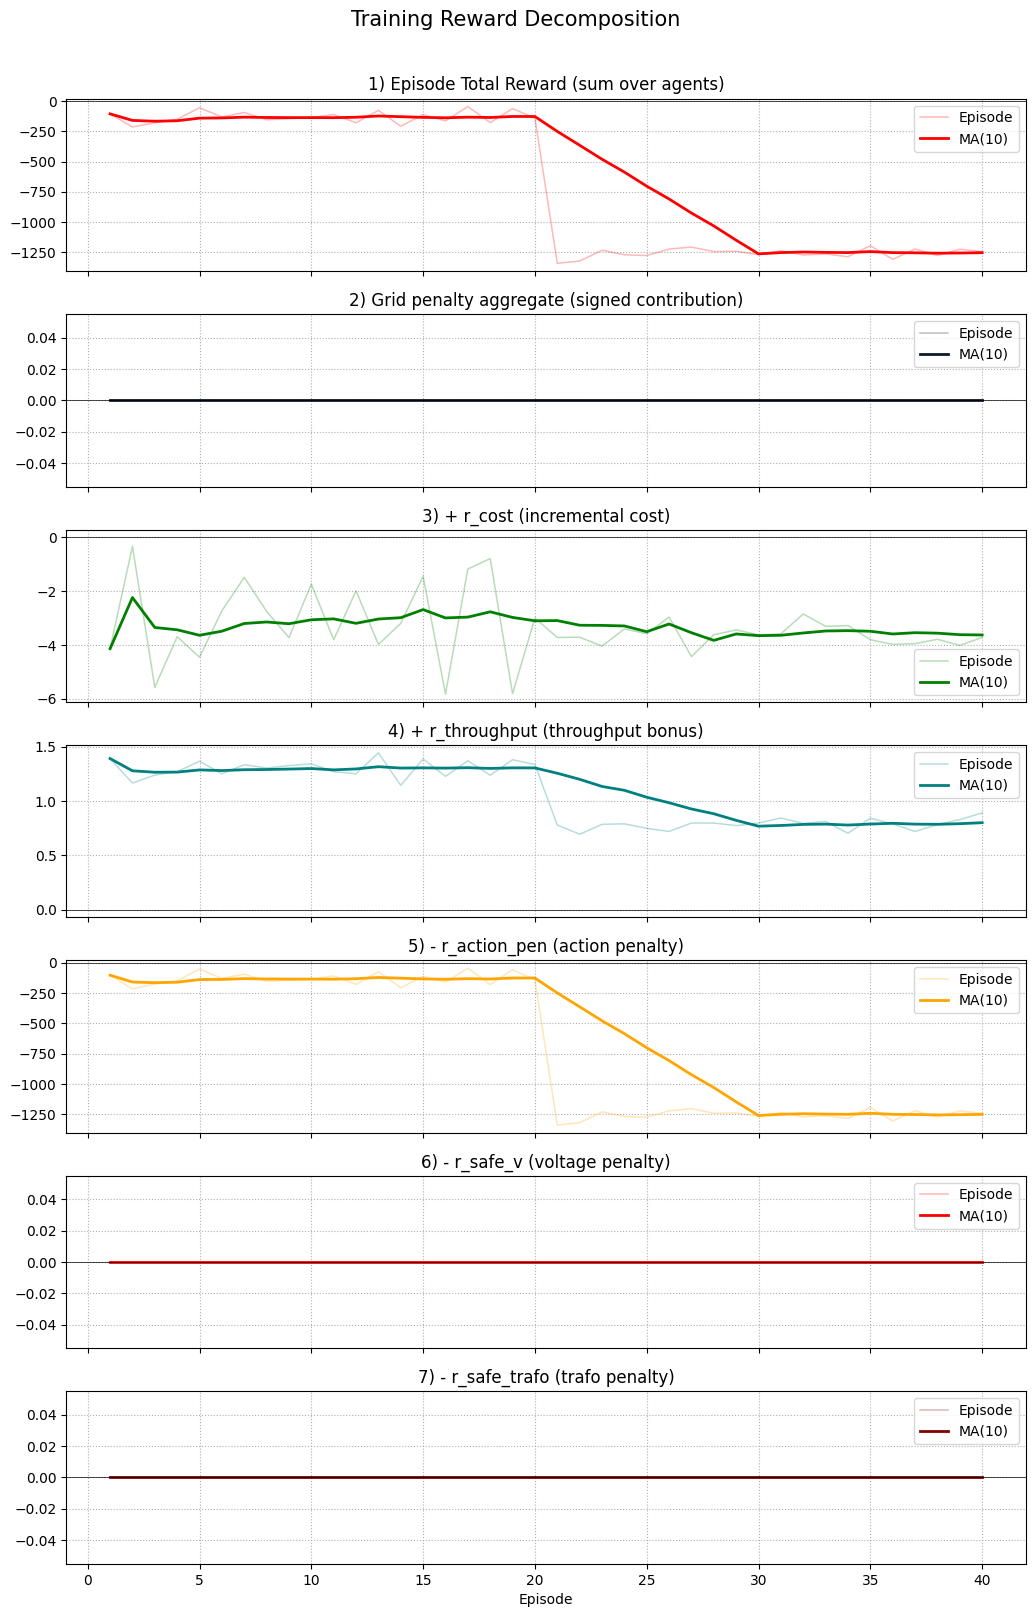

In [ ]:
print(f"Reward summary path: {reward_summary_path}")
plot_reward_decomposition(
    reward_summary=reward_summary_path,
    title='Training Reward Decomposition',
    window=reward_plot_window,
);


In [ ]:
print(f"External mainline already saved the model to: {save_dir}")
print(f"Reward summary saved to: {reward_summary_path}")
print(f"Progress snapshot: {progress_path}")


External mainline already saved the model to: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep500_20260325_172921
Reward summary saved to: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep500_20260325_172921\_meta\train_reward_summary.json
Progress snapshot: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep500_20260325_172921\_meta\progress.json


In [ ]:
cfg.algo.name = algorithm

selected_model_root = resolve_madrl_model_root(
    model_root=test_controls["model_root"],
    root=project_root,
    checkpoint_root=checkpoint_controls["checkpoint_root"],
    algorithm=algorithm,
    prediction_mode=applied_controls["prediction_mode"],
    experiment_name=checkpoint_controls["experiment_name"],
)
selected_episode_tag = test_controls["episode_tag"]
if selected_episode_tag is None and train_result is not None:
    selected_episode_tag = int(train_result.get("saved_episode_tag", episodes_completed))

print(f"Selected model root: {selected_model_root}")
print(f"Selected episode tag: {selected_episode_tag if selected_episode_tag is not None else 'latest'}")

drl_rollout = collect_madrl_rollout(
    cfg,
    model_root=selected_model_root,
    algorithm=algorithm,
    episode_tag=selected_episode_tag,
    experiment_name=checkpoint_controls["experiment_name"],
    checkpoint_root=checkpoint_controls["checkpoint_root"],
)
cost_summary = drl_rollout.summary
cost_summary


Selected model root: D:\GithubProject\MADRL_ESS\artifacts\training\checkpoints\MATD3\normal\grid_mainline\matd3_normal_grid_mainline_ep50_20260326_104831
Selected episode tag: 40


,controller,agent_profile,operating_cost
0,DRL (forecast_eval),SFH12,-59.142242
1,DRL (forecast_eval),SFH14,-62.650283
2,DRL (forecast_eval),SFH16,-65.665349


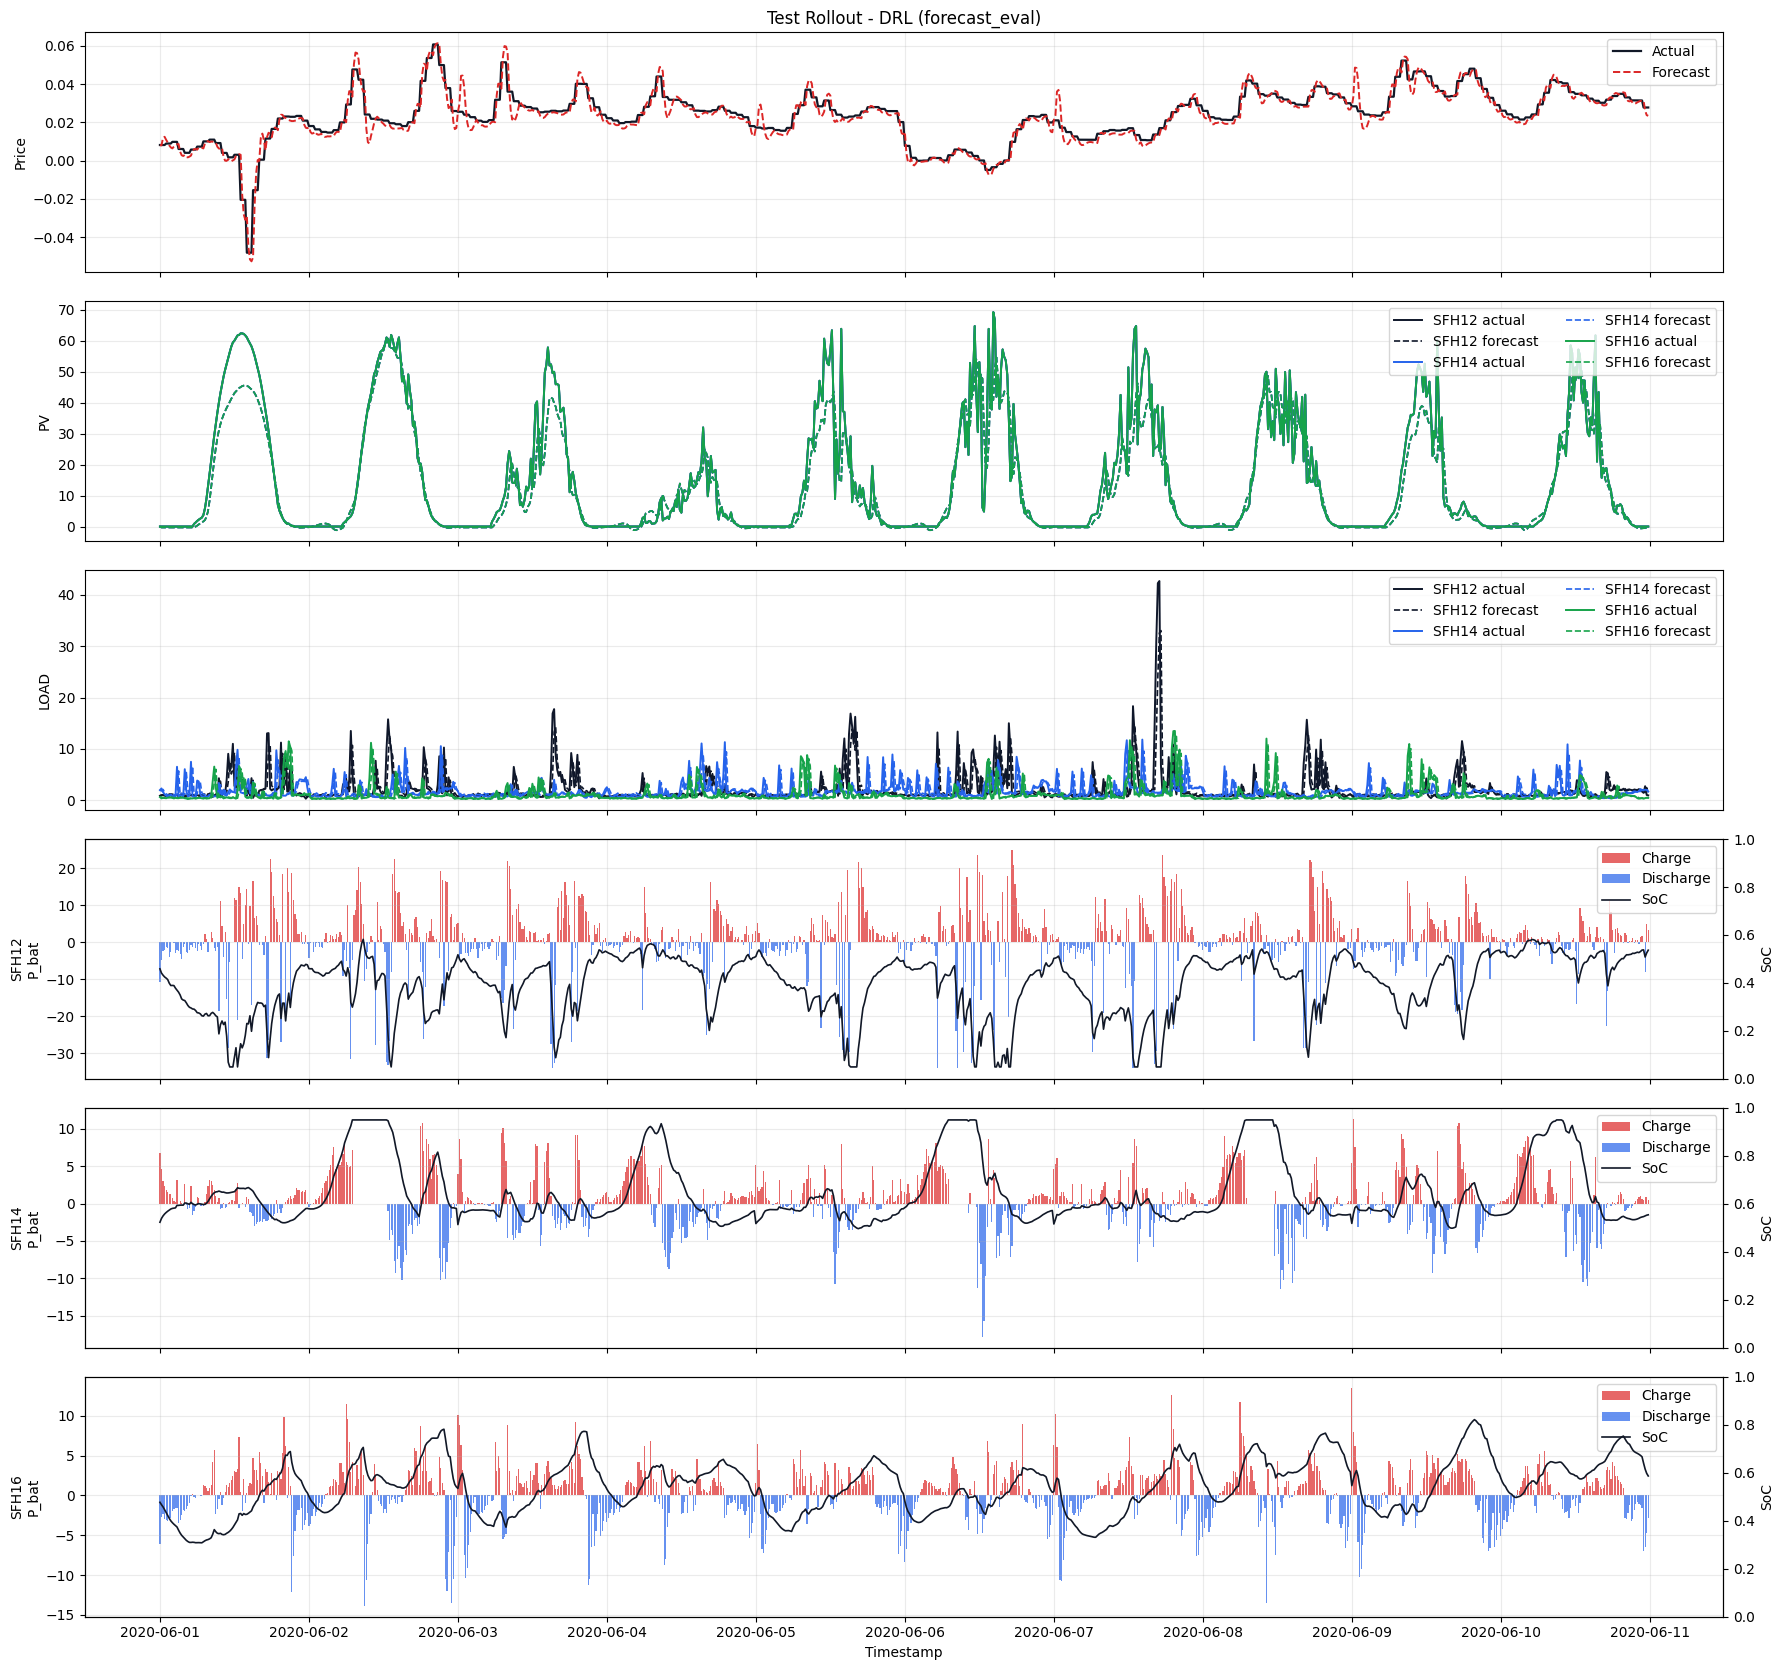

In [ ]:
plot_rollout_dashboard(drl_rollout);


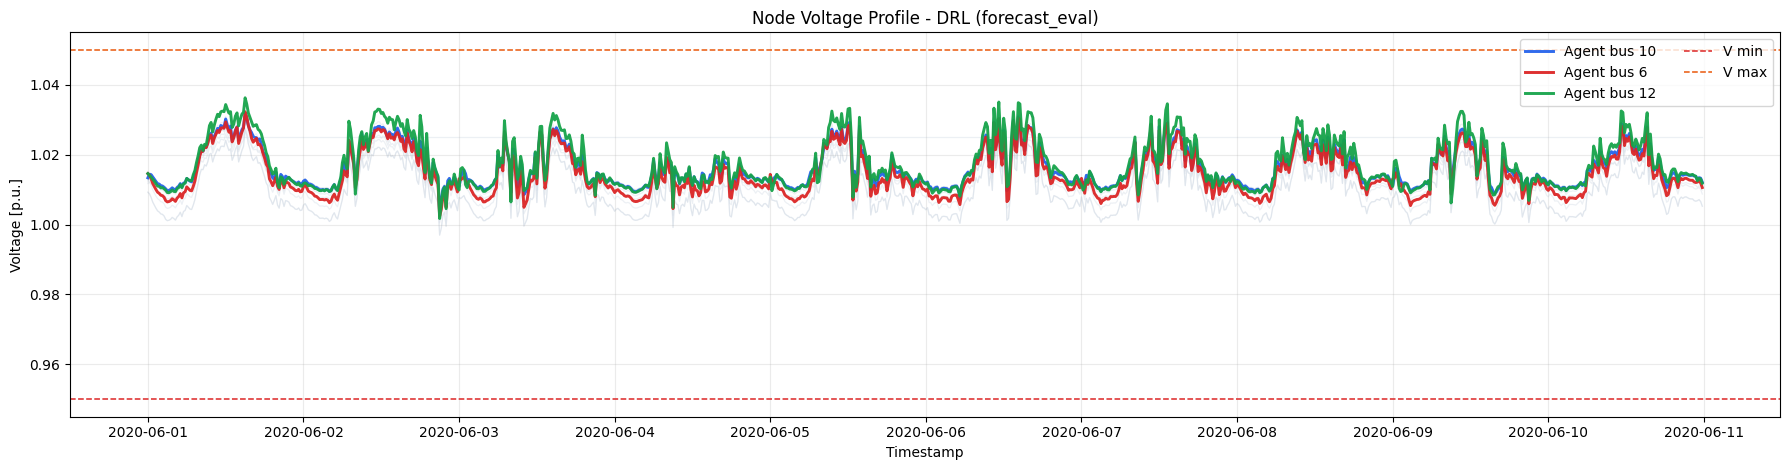

In [ ]:
normal_mpc_cfg = build_comparison_cfg(cfg, prediction_mode='normal')
normal_forecast_ready = ensure_forecast_ready(normal_mpc_cfg)

mpc_normal_rollout = collect_mpc_rollout(cfg, prediction_mode='normal', label='MPC (forecast_eval)')
mpc_perfect_rollout = collect_mpc_rollout(cfg, prediction_mode='perfect', label='MPC (oracle_eval)')


In [ ]:
plot_rollout_dashboard(mpc_perfect_rollout);


,controller,total_operating_cost
0,MPC (oracle_eval),-257.542161
1,MPC (forecast_eval),-206.257233
2,DRL (forecast_eval),-187.457874


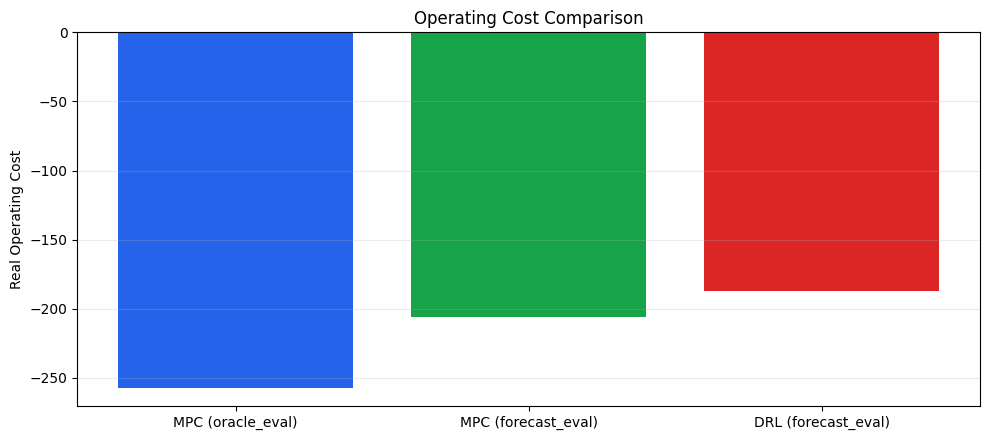

In [ ]:
plot_rollout_dashboard(mpc_normal_rollout);


In [ ]:
comparison_df = compare_rollout_metrics(mpc_perfect_rollout, mpc_normal_rollout, drl_rollout)
comparison_df


In [ ]:
plot_rollout_comparison_dashboard(comparison_df);
